In [285]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdDetermineBonds
import py3Dmol

In [286]:
def mol2d_to_3d(molecule):
    mol = Chem.Mol(molecule)
    mol = AllChem.AddHs(mol, addCoords=True)
    AllChem.EmbedMolecule(mol)
    AllChem.MMFFOptimizeMolecule(mol)
    return mol

In [287]:
def xyzfile_to_mol3d(xyz_file):
    """
    Convert an XYZ file to an RDKit molecule with 3D coordinates

    Parameters:
    xyz_file (str): Path to the XYZ file.

    Returns:
    rdkit.Chem.Mol: RDKit molecule with 3D coordinates.
    """
    mol = Chem.MolFromXYZFile(xyz_file)
    mol = Chem.Mol(mol)
    Chem.SanitizeMol(mol)
    rdDetermineBonds.DetermineConnectivity(mol)
    try:
        rdDetermineBonds.DetermineBondOrders(mol)
    except ValueError:
        # If it fails, we keep the bonds from step 2 (usually inferred as Single)
        pass

    return mol

In [288]:
# Import datasets: from xyz to rdkit 3D mol
dataset_path = "/home/cds/rketkaew/dataset/Grambow-R-TS-P-dataset/wb97xd3_xyz/"

mols_3d_r, mols_3d_ts, mols_3d_p = [], [], []
for i in range(3):
       mols_3d_r.append(xyzfile_to_mol3d(dataset_path + f"r{i:06d}.xyz"))
       mols_3d_ts.append(xyzfile_to_mol3d(dataset_path + f"ts{i:06d}.xyz"))
       mols_3d_p.append(xyzfile_to_mol3d(dataset_path + f"p{i:06d}.xyz"))

print(len(mols_3d_r), len(mols_3d_ts), len(mols_3d_p))

3 3 3


### Display 3D and 2D structures

In [289]:
# Display 3D structure
view = py3Dmol.view(
    width=300, height=300,
    data=Chem.MolToMolBlock(mols_3d_r[0]),  # Convert the RDKit molecule for py3Dmol
    style={"stick": {}, "sphere": {"scale": 0.3}}
)
view.zoomTo()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

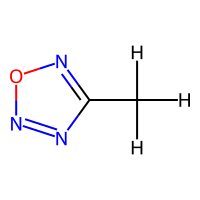

In [290]:
# Display 2D structure 
mol_2d = Chem.Mol(mols_3d_r[0]) # copy to a new mol to avoid unwanted modication
AllChem.Compute2DCoords(mol_2d)
dos = Draw.MolDrawOptions()
# dos.addAtomIndices=True
Draw.MolToImage(mol_2d, options=dos, size=(200, 200))

## Display 3D and 2D structures in Grid

['Reactant', 'Ts', 'Product', 'Reactant', 'Ts', 'Product', 'Reactant', 'Ts', 'Product']


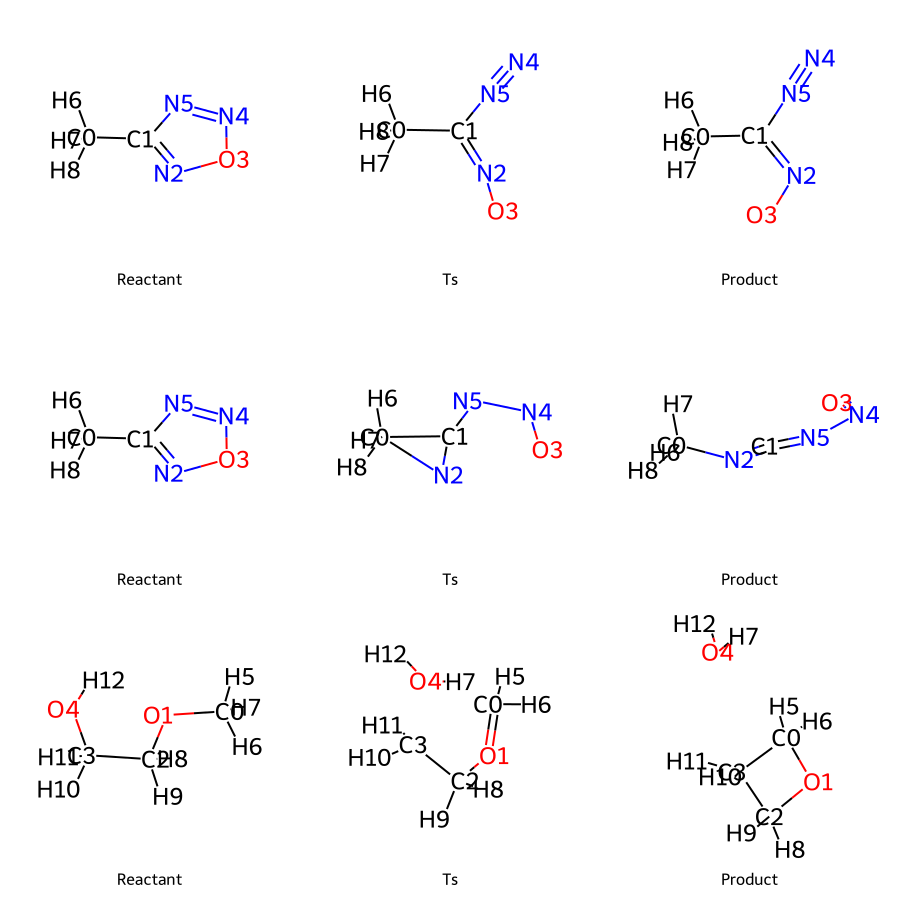

In [291]:
# Dusplay 3D structures
mols_3d_combined = []
for r, ts, p in zip(mols_3d_r, mols_3d_ts, mols_3d_p):
    mols_3d_combined.extend([r, ts, p])

# Add atom labels (Symbol + Index)
for mol in mols_3d_combined:
    for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", f"{atom.GetSymbol()}{atom.GetIdx()}")

mol_legends = ["Reactant", "Ts", "Product"] * len(mols_3d_r)
print(mol_legends)

Draw.MolsToGridImage(mols_3d_combined, legends=mol_legends, molsPerRow=3, subImgSize=(300, 300))

In [292]:
num_reactions = 3

view = py3Dmol.view(width=900, height=300 * num_reactions, viewergrid=(num_reactions, 3))

for i in range(num_reactions):
    # Use the original molecules directly since they already have 3D coordinates from XYZ files
    mol_r = mols_3d_r[i]
    mol_ts = mols_3d_ts[i]
    mol_p = mols_3d_p[i]
    
    row_mols = [mol_r, mol_ts, mol_p]
    
    for j, mol in enumerate(row_mols):
        view.addModel(Chem.MolToMolBlock(mol), "mol", viewer=(i, j))
        
        # Add atomic labels
        for atom in mol.GetAtoms():
            pos = mol.GetConformer().GetAtomPosition(atom.GetIdx())
            label = f"{atom.GetSymbol()}{atom.GetIdx()}"
            view.addLabel(label, {
                "position": {"x": pos.x, "y": pos.y, "z": pos.z},
                "fontSize": 12,
                "fontColor": "black",
                "backgroundColor": "white",
                "showBackground": True,
                "backgroundOpacity": 0.7
            }, viewer=(i, j))

view.setStyle({"stick": {"radius": 0.2}, "sphere": {"scale": 0.4}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

['Reactant', 'Ts', 'Product', 'Reactant', 'Ts', 'Product', 'Reactant', 'Ts', 'Product']


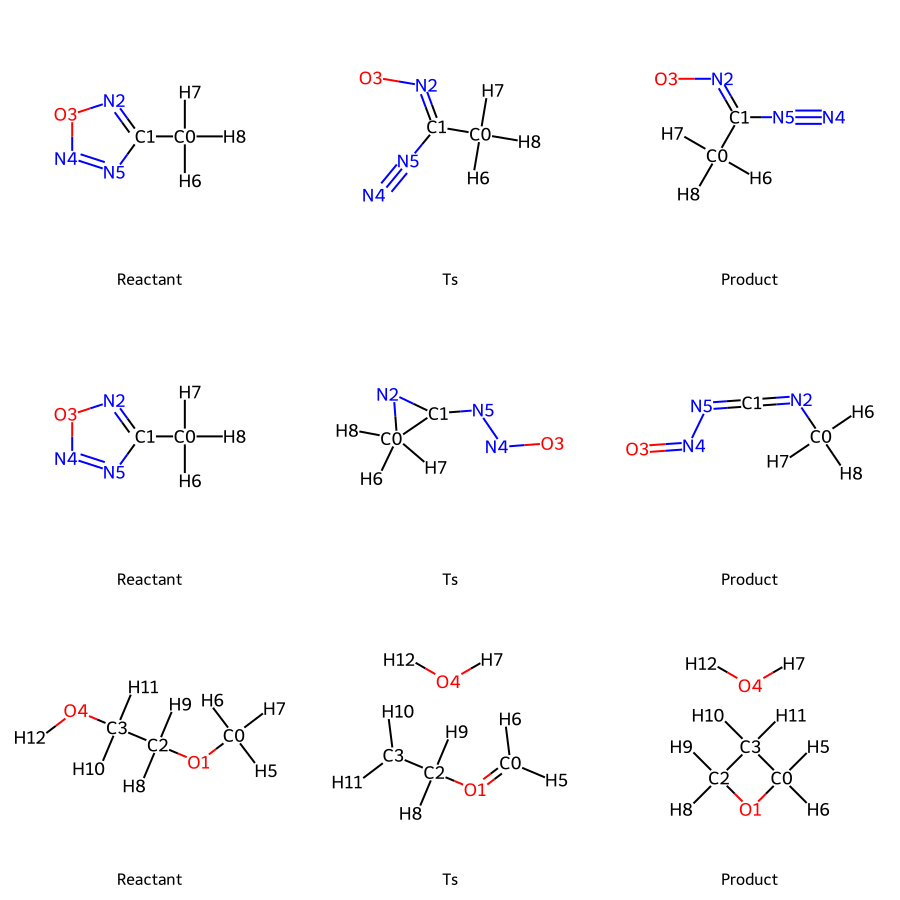

In [293]:
# Display 2D structures (we need to convert 3D to 2D first)
mols_2d_combined = []
for r, ts, p in zip(mols_3d_r, mols_3d_ts, mols_3d_p):
    r_2d = Chem.Mol(r)
    ts_2d = Chem.Mol(ts)
    p_2d = Chem.Mol(p)
    
    # Generate 2D coordinates to prevent overlap
    AllChem.Compute2DCoords(r_2d)
    AllChem.Compute2DCoords(ts_2d)
    AllChem.Compute2DCoords(p_2d)
    mols_2d_combined.extend([r_2d, ts_2d, p_2d])

# Add atom labels (Symbol + Index)
for mol in mols_2d_combined:
    for atom in mol.GetAtoms():
        atom.SetProp("atomLabel", f"{atom.GetSymbol()}{atom.GetIdx()}")

mol_legends = ["Reactant", "Ts", "Product"] * len(mols_3d_r)
print(mol_legends)

Draw.MolsToGridImage(mols_2d_combined, legends=mol_legends, molsPerRow=3, subImgSize=(300, 300))

## Display structures and highlight changing atoms

In [294]:
def get_reaction_center_atoms(mol_reactant, mol_product):
    """
    Compares reactant and product to identify atoms involved in 
    bond breaking, formation, or bond order changes.
    
    Atom indices between the two molecules are assumed to match.
    """
    changed_atoms = set()
    
    # 1. Check bonds in reactant
    for bond_r in mol_reactant.GetBonds():
        a1, a2 = bond_r.GetBeginAtomIdx(), bond_r.GetEndAtomIdx()
        bond_p = mol_product.GetBondBetweenAtoms(a1, a2)
        
        if bond_p is None:
            # Bond exists in R but not in P (Bond break)
            changed_atoms.add(a1)
            changed_atoms.add(a2)
        elif bond_r.GetBondType() != bond_p.GetBondType():
            # Bond exists in both but order changed (e.g., single -> double)
            changed_atoms.add(a1)
            changed_atoms.add(a2)
            
    # 2. Check bonds in product (to find completely new bonds)
    for bond_p in mol_product.GetBonds():
        a1, a2 = bond_p.GetBeginAtomIdx(), bond_p.GetEndAtomIdx()
        bond_r = mol_reactant.GetBondBetweenAtoms(a1, a2)
        
        if bond_r is None:
            # Bond exists in P but not in R (Bond formation)
            changed_atoms.add(a1)
            changed_atoms.add(a2)
            
    return list(changed_atoms)

Number of reactions: 3
Indices of atoms involved in the reaction: [1, 2, 3, 4, 5]
Indices of atoms involved in the reaction: [0, 1, 2, 3, 4, 5]
Indices of atoms involved in the reaction: [0, 3, 4, 7]


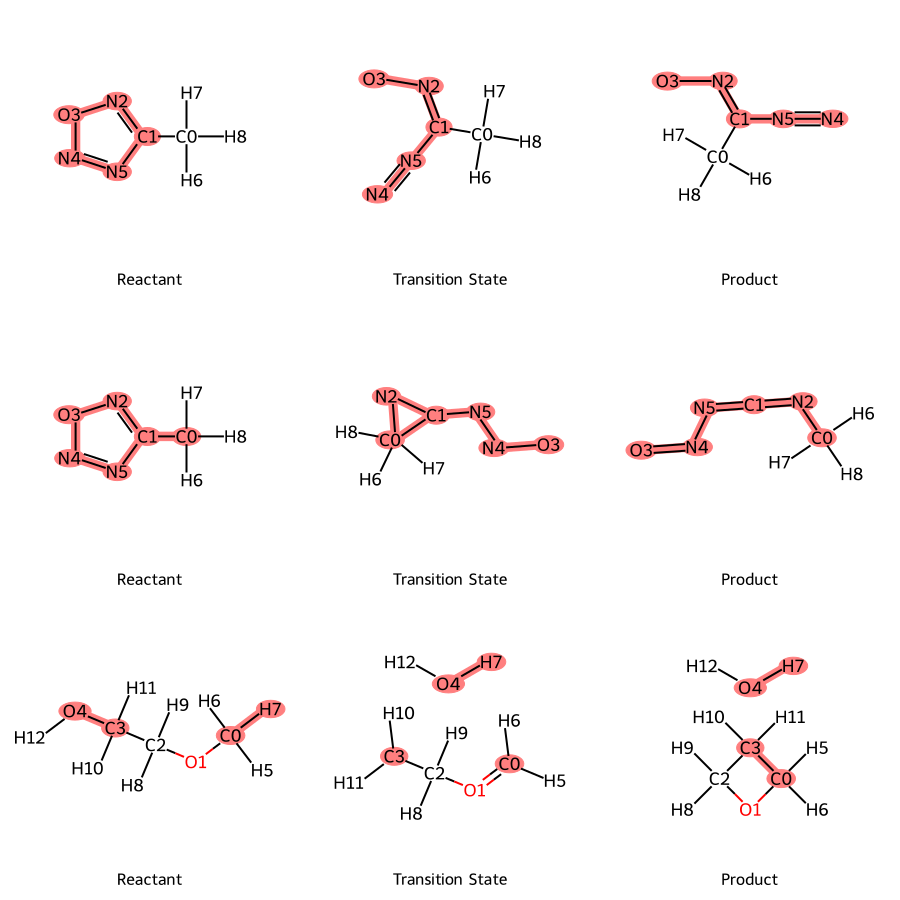

In [297]:
print(f"Number of reactions: {len(mols_2d_combined)//3}")
titles = ["Reactant", "Transition State", "Product"] * (len(mols_2d_combined)//3)
highlights = []
for i in range(0, len(mols_2d_combined), 3):
    active_atoms = get_reaction_center_atoms(mols_2d_combined[i], mols_2d_combined[i+2])

    print(f"Indices of atoms involved in the reaction: {active_atoms}")
    highlights.extend([active_atoms, active_atoms, active_atoms])

Draw.MolsToGridImage(
    mols_2d_combined,
    molsPerRow=3,
    subImgSize=(300, 300),
    legends=titles,
    highlightAtomLists=highlights,
    useSVG=True
)
